In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

from collections import Counter

from imblearn.over_sampling import SMOTE


# Import the visualization library I prepared for you
! wget https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py
from visualization import plot_conf_mat, plot_feature_importances


!pip install ipython-autotime # To show time at each cell
                              # Credits to https://medium.com/@arptoth/how-to-measure-execution-time-in-google-colab-707cc9aad1c8
%load_ext autotime


# The following is to be able to mount Google Drive
from google.colab import drive

import pickle # To save the model
from os.path import isfile

--2025-06-27 08:00:03--  https://raw.githubusercontent.com/andreaaraldo/machine-learning-for-networks/master/course_library/visualization.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13023 (13K) [text/plain]
Saving to: ‘visualization.py’

visualization.py    100%[===================>]  12.72K  --.-KB/s    in 0.001s  

2025-06-27 08:00:03 (21.0 MB/s) - ‘visualization.py’ saved [13023/13023]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.5 MB/s eta 0:00:00
time: 365 µs (started: 2025-06-27 08:00:16 +00:00)


In [2]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_test.csv

--2025-06-27 08:00:16--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 308116 (301K) [text/plain]
Saving to: ‘X_test.csv’

X_test.csv          100%[===================>] 300.89K  --.-KB/s    in 0.04s   

2025-06-27 08:00:17 (6.78 MB/s) - ‘X_test.csv’ saved [308116/308116]

time: 204 ms (started: 2025-06-27 08:00:16 +00:00)


In [3]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/y_train.csv

--2025-06-27 08:00:17--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/y_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136635 (133K) [text/plain]
Saving to: ‘y_train.csv’

y_train.csv         100%[===================>] 133.43K  --.-KB/s    in 0.02s   

2025-06-27 08:00:17 (5.23 MB/s) - ‘y_train.csv’ saved [136635/136635]

time: 203 ms (started: 2025-06-27 08:00:17 +00:00)


In [4]:
! wget https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_train.csv

--2025-06-27 08:00:17--  https://raw.githubusercontent.com/Robert-ung/machine-learning-for-networks/refs/heads/main/X_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 927653 (906K) [text/plain]
Saving to: ‘X_train.csv’

X_train.csv         100%[===================>] 905.91K  --.-KB/s    in 0.06s   

2025-06-27 08:00:17 (15.5 MB/s) - ‘X_train.csv’ saved [927653/927653]

time: 408 ms (started: 2025-06-27 08:00:17 +00:00)


In [5]:
df_X_train = pd.read_csv("X_train.csv", index_col=0)
df_X_test = pd.read_csv("X_test.csv", index_col=0)
df_y_train = pd.read_csv("y_train.csv", index_col=0)

time: 66.4 ms (started: 2025-06-27 08:00:17 +00:00)


In [6]:
df_X_train.head()

,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_16_categ,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee
0,18702,2014,1,0,V,N,1,O,1,O,...,IDENTIQUE,V,base,2,1351.0,4,2012.0,0.0,2,65440
1,3877,2014,1,0,V,V,V,V,V,V,...,V,N,base,2,1972.0,2,1980.0,0.0,.,14341
2,4942,2013,1,1,V,V,V,V,V,V,...,V,N,base,2,1630.0,4,NaN,0.0,.,75109
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,V,N,base,2,532.0,3,NaN,0.0,.,92004
4,17137,2015,1,0,V,N,2,O,1,O,...,IDENTIQUE,V,base,2,1050.0,2,1972.0,0.0,4,59340


time: 26.1 ms (started: 2025-06-27 08:00:17 +00:00)


In [7]:
# Fusionner X et y sur 'Identifiant'
df_train = df_X_train.merge(df_y_train, on="Identifiant")
df_train.head()

,Identifiant,ft_2_categ,EXPO,ft_4_categ,ft_5_categ,ft_6_categ,ft_7_categ,ft_8_categ,ft_9_categ,ft_10_categ,...,ft_17_categ,ft_18_categ,ft_19_categ,superficief,ft_21_categ,ft_22_categ,ft_23_categ,ft_24_categ,Insee,target
0,18702,2014,1,0,V,N,1,O,1,O,...,V,base,2,1351.0,4,2012.0,0.0,2,65440,0
1,3877,2014,1,0,V,V,V,V,V,V,...,N,base,2,1972.0,2,1980.0,0.0,.,14341,1
2,4942,2013,1,1,V,V,V,V,V,V,...,N,base,2,1630.0,4,NaN,0.0,.,75109,0
3,13428,2013,"0,246575342",0,N,V,V,V,V,V,...,N,base,2,532.0,3,NaN,0.0,.,92004,0
4,17137,2015,1,0,V,N,2,O,1,O,...,V,base,2,1050.0,2,1972.0,0.0,4,59340,0


time: 29.5 ms (started: 2025-06-27 08:00:17 +00:00)


In [8]:
df_train = df_train.drop(labels=['Identifiant', 'ft_2_categ', 'ft_22_categ', 'Insee', 'ft_4_categ', 'ft_5_categ', 'ft_6_categ', 'ft_7_categ', 'ft_8_categ', 'ft_9_categ', 'ft_10_categ', 'ft_11_categ', 'ft_12_categ', 'ft_13_categ', 'ft_14_categ', 'ft_15_categ', 'ft_16_categ', 'ft_17_categ', 'ft_18_categ', 'ft_19_categ', 'ft_21_categ', 'ft_23_categ', 'ft_24_categ'], axis=1)

time: 1.44 ms (started: 2025-06-27 08:00:17 +00:00)


In [9]:
df_train.head()

,EXPO,superficief,target
0,1,1351.0,0
1,1,1972.0,1
2,1,1630.0,0
3,"0,246575342",532.0,0
4,1,1050.0,0


time: 18.9 ms (started: 2025-06-27 08:00:17 +00:00)


In [10]:
# Nettoyage des données (corriger les virgules, convertir en float)

df_train_cleaned = df_train.copy()
df_train_cleaned['EXPO'] = df_train_cleaned['EXPO'].str.replace(',', '.').astype(float)
for col in df_train_cleaned.columns:
    if df_train_cleaned[col].dtype == 'object':
        df_train_cleaned[col] = df_train_cleaned[col].str.replace(',', '.', regex=False)
        try:
            df_train_cleaned[col] = df_train_cleaned[col].astype(float)
        except:
            pass

df_X_test_cleaned = df_X_test.copy()
df_X_test_cleaned['EXPO'] = df_X_test_cleaned['EXPO'].str.replace(',', '.').astype(float)
for col in df_X_test_cleaned.columns:
    if df_X_test_cleaned[col].dtype == 'object':
        df_X_test_cleaned[col] = df_X_test_cleaned[col].str.replace(',', '.', regex=False)
        try:
            df_X_test_cleaned[col] = df_X_test_cleaned[col].astype(float)
        except:
            pass

time: 42.2 ms (started: 2025-06-27 08:00:17 +00:00)


In [11]:
# Supprimer les lignes avec des NaN
df_train_cleaned = df_train_cleaned.dropna()
df_X_test_cleaned = df_X_test_cleaned.dropna()

time: 9.87 ms (started: 2025-06-27 08:00:17 +00:00)


In [12]:
X = df_train_cleaned.drop(labels='target', axis=1)
y = df_train_cleaned['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,
                                        shuffle=True, random_state=4)

time: 6.17 ms (started: 2025-06-27 08:00:17 +00:00)


In [13]:
print( "Samples per class before SMOTE: ", Counter(y_train) )

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

print( "Samples per class after SMOTE: ", Counter(y_train) )

Samples per class before SMOTE:  Counter({0: 5433, 1: 1644})
Samples per class after SMOTE:  Counter({1: 5433, 0: 5433})
time: 20.6 ms (started: 2025-06-27 08:00:17 +00:00)


In [14]:
model = RandomForestClassifier(n_estimators=100,
                      criterion='gini',
                      max_leaf_nodes=16, # Each tree cannot have more than that
                      random_state=5, # For reproducibility
                      n_jobs=-1, # Use all the CPUs
                      )

model.fit(X_train, y_train)

RandomForestClassifier(max_leaf_nodes=16, n_jobs=-1, random_state=5)

time: 911 ms (started: 2025-06-27 08:00:17 +00:00)


Normalized confusion matrix
[[0.67185528 0.32814472]
 [0.40396341 0.59603659]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

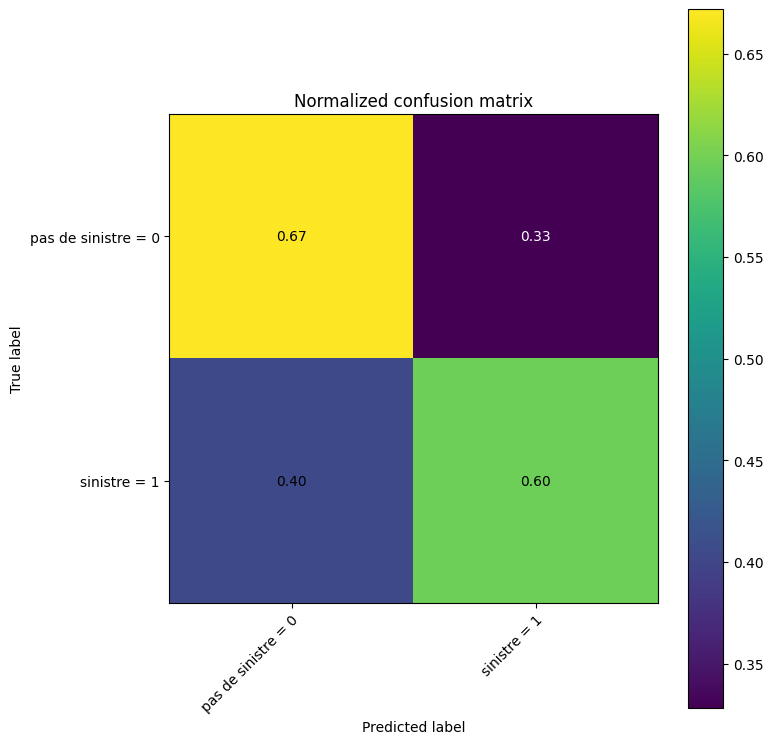

time: 1.27 s (started: 2025-06-27 08:00:18 +00:00)


In [15]:
y_pred = model.predict(X_test)

class_names = np.array(['pas de sinistre = 0', 'sinistre = 1'])
plot_conf_mat(y_test, y_pred, class_names)

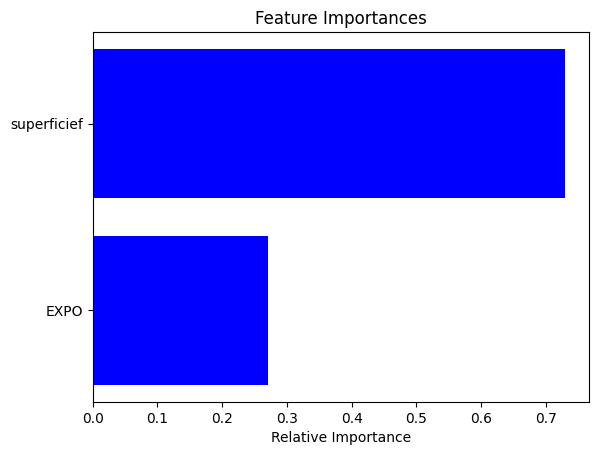

Index(['EXPO', 'superficief'], dtype='object')

time: 768 ms (started: 2025-06-27 08:00:20 +00:00)


In [16]:
feature_names = X_test.columns
plot_feature_importances(model.feature_importances_, feature_names)
feature_names

In [17]:
 param_grid = {
    'criterion':['gini', 'entropy'],
    'max_features':[1,2,3,4,5],

    # Number of allowed leafs
    'max_leaf_nodes':[16, 32, 64, 128, 256, 512, 1024, 2048],

    # A node will be split if this split induces a decrease of the
    # impurity greater than or equal to this value.
    'min_impurity_decrease' : [0, 0.001, 0.01, 0.1, 0.2],

    'max_depth':[1,10,100,1000,10000,100000],

    # A node can be a leaf only if it contains at least the following fraction
    # of samples
    'min_weight_fraction_leaf' : [0.1, 0.01, 0.001, 0]

}

time: 930 µs (started: 2025-06-27 08:00:20 +00:00)


In [18]:
# Before we had used all the availble CPUs for training one random forest.
# Now, instead, we use one CPU per random forest (n_jobs=1).
forest = RandomForestClassifier(n_estimators=100, random_state = 4, n_jobs=1,)


search = RandomizedSearchCV(
                            scoring = 'accuracy', # See other possible metrics in
                                                # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

                            estimator=forest,
                            param_distributions=param_grid,
                            n_iter=50, # We just test 50 configurations
                            verbose=2,random_state=42,
                            n_jobs=-1, # Triain forests in parallel using
                                      # all CPUs
                            cv=5 # 5-fold validation
                          )
# Note that we are training different random forests in parallel (n_jobs=-1),
# each with a certain combination of hyper-parameters.

search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=1, random_state=4),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 10, 100, 1000, 10000,
                                                      100000],
                                        'max_features': [1, 2, 3, 4, 5],
                                        'max_leaf_nodes': [16, 32, 64, 128, 256,
                                                           512, 1024, 2048],
                                        'min_impurity_decrease': [0, 0.001,
                                                                  0.01, 0.1,
                                                                  0.2],
                                        'min_weight_fraction_leaf': [0.1, 0.01,
                                                                     0.001,
                                                                     0]},
                   random_state=42, scoring='accuracy', verbose=2)

time: 1min 24s (started: 2025-06-27 08:00:20 +00:00)


In [19]:
print(search.best_params_)

model = search.best_estimator_

{'min_weight_fraction_leaf': 0.001, 'min_impurity_decrease': 0.001, 'max_leaf_nodes': 32, 'max_features': 5, 'max_depth': 10000, 'criterion': 'entropy'}
time: 1.56 ms (started: 2025-06-27 08:01:45 +00:00)


Normalized confusion matrix
[[0.67732436 0.32267564]
 [0.41006098 0.58993902]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

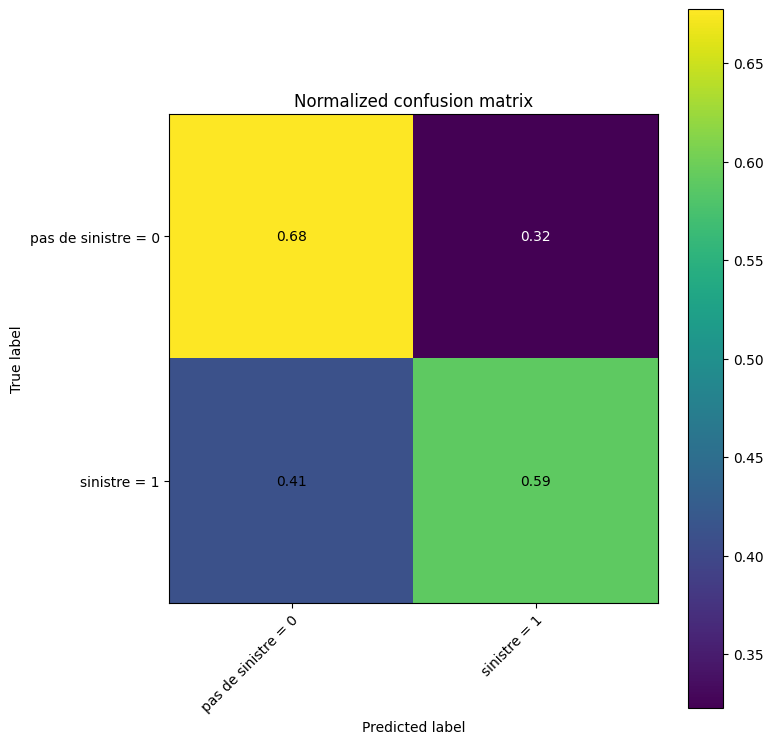

time: 1.03 s (started: 2025-06-27 08:01:45 +00:00)


In [20]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plot_conf_mat(y_test, y_pred, class_names)

Accuracy: 0.78
Normalized confusion matrix
[[1. 0.]
 [1. 0.]]


<Axes: title={'center': 'Normalized confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

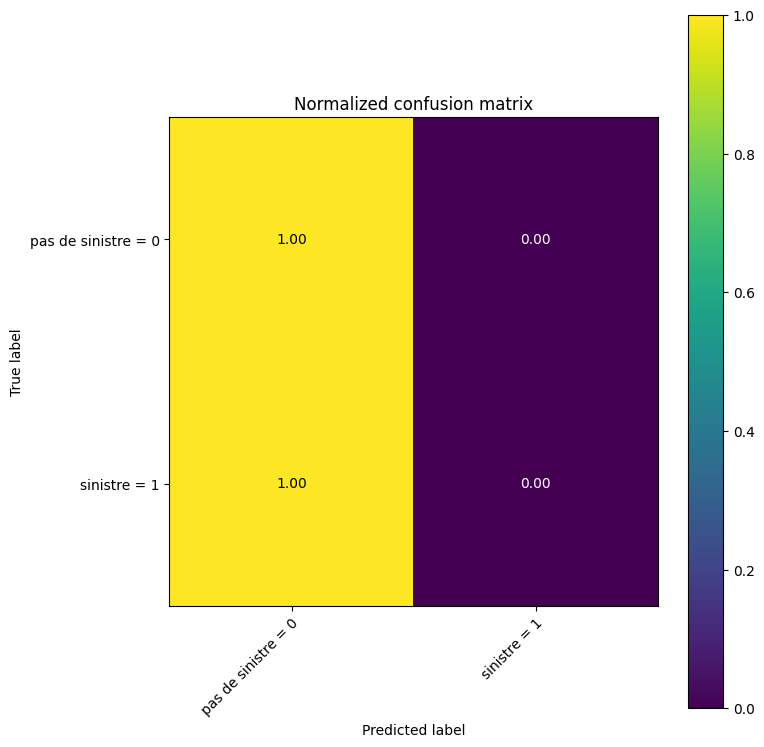

time: 6.72 s (started: 2025-06-27 09:06:58 +00:00)


In [40]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
"""
model = MLPClassifier(
    activation="tanh",
    alpha=0.001,
    batch_size=128,
    early_stopping=True,
    hidden_layer_sizes=(40, 20, 20),
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    validation_fraction=0.1,
    n_iter_no_change=10
)
"""

model = MLPClassifier(
    activation="relu",
    alpha=0.05505447268447255,
    batch_size=16,
    hidden_layer_sizes=(40, 40),
    learning_rate_init=0.009672524312471559,
    max_iter=680,
    random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
plot_conf_mat(y_test, y_pred, class_names)


In [33]:
from scipy.stats import uniform, randint

# Define the model
model = MLPClassifier(random_state=42)

# Define the parameter grid
param_distributions = {
    'hidden_layer_sizes': [(10,), (20,), (30,), (40,), (50,), (40, 40), (50, 50, 30)],
    'activation': ['logistic', 'tanh', 'relu'],
    'alpha': uniform(0.0001, 0.1),  # Uniform distribution for alpha
    'learning_rate_init': uniform(0.0001, 0.01),  # Uniform distribution for learning rate
    'max_iter': randint(100, 1000),  # Random integer for max_iter
    'batch_size': [16, 32, 64, 128]
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    model,
    param_distributions,
    n_iter=10,  # Number of parameter combinations to try
    scoring='accuracy',
    cv=5,  # 5-fold cross-validation
    random_state=45,
    n_jobs=-1  # Use all available cores
)

# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_

# Evaluate the best model on the test set
best_model = random_search.best_estimator_
test_score = best_model.score(X_test, y_test)

print(f'Best Parameters: {best_params}')
print(f'Best Cross-Validation Score: {best_score:.2f}')
print(f'Test Set Score: {test_score:.2f}')

Best Parameters: {'activation': 'relu', 'alpha': np.float64(0.05505447268447255), 'batch_size': 16, 'hidden_layer_sizes': (40, 40), 'learning_rate_init': np.float64(0.009672524312471559), 'max_iter': 680}
Best Cross-Validation Score: 0.58
Test Set Score: 0.78
time: 2min 51s (started: 2025-06-27 08:15:47 +00:00)
